In [31]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns

# S3-VAE with batch normalization:

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=2, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Dynamically compute final feature map size
        dummy_input = torch.zeros(1, 2, img_size, img_size)  # Fake input to infer shape
        with torch.no_grad():
            dummy_output = self.conv4(self.conv3(self.conv2(self.conv1(dummy_input))))
        self.final_size = dummy_output.shape[-1]  # Get actual final size (should be 8)

        self.fc_mu = nn.Linear(256 * self.final_size * self.final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * self.final_size * self.final_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        #x = self.bn1(F.relu(self.conv1(x)))
        #x = self.bn2(F.relu(self.conv2(x)))
        #x = self.bn3(F.relu(self.conv3(x)))
        #x = self.bn4(F.relu(self.conv4(x)))

        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=2, img_size=140):
        super(Decoder, self).__init__()

        # Ensure consistency with encoder
        self.final_size = 8  # Since we dynamically compute it in Encoder, we ensure it's consistent
        self.fc = nn.Linear(latent_dim, 256 * self.final_size * self.final_size)  

        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(128)

        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.deconv4 = nn.ConvTranspose2d(32, 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        # Final Upsampling to ensure exact output size
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)


    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = torch.sigmoid(self.deconv4(x))  # Output is 140x140 now
        #x = self.bn1(F.relu(self.deconv1(x)))  # (128, 17, 17)
        #x = self.bn2(F.relu(self.deconv2(x)))  # (64, 35, 35)
        #x = self.bn3(F.relu(self.deconv3(x)))  # (32, 70, 70)
        #x = torch.sigmoid(self.deconv4(x)) 
        x = self.final_upsample(x)  # Ensure output size is exactly 140x140
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=2, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    
    

# S3-VAE with maxPooling:

In [ ]:

class Encoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.MaxPool2d(2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.MaxPool2d(2)
        
        final_size = img_size // 16
        self.fc_mu = nn.Linear(256 * final_size * final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * final_size * final_size, latent_dim)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Decoder, self).__init__()
        
        final_size = img_size // 16
        self.fc = nn.Linear(latent_dim, 256 * final_size * final_size)
        
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1)
        self.deconv4 = nn.Conv2d(32, 2, kernel_size=3, stride=1, padding=1)
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)  # Ensures exact size

        
    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = F.relu(self.deconv4(x))
        x = torch.sigmoid(self.final_upsample(x))
        return x
    
    
class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    

In [3]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
btk_dataset = MarkerDataset("CD38")
btk_loader = DataLoader(btk_dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(btk_loader)}")

Total batches: 64


In [4]:
print(f"Number of images in dataset: {len(btk_dataset)}")
print(f"Number of batches in DataLoader: {len(btk_loader)}")

Number of images in dataset: 2028
Number of batches in DataLoader: 64


In [5]:
img, label, patient_id = btk_dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(btk_dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(btk_dataset)}")

Image shape: torch.Size([2, 140, 140])
Image max value: 0.5738561749458313
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2028


In [6]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)
            # Visualize first 5 images and their reconstructions
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):
                # Original
                axes[0, i].imshow(images[i, 1].cpu().numpy(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")
                # Reconstructed
                axes[1, i].imshow(recon_images[i, 1].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")
            plt.show()
            break

In [10]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)

            fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 4 rows: original (2 channels) + reconstructed (2 channels)

            for i in range(5):  # Show 5 images
                for j in range(2):  # Loop over the 2 channels
                    # Original images
                    img_orig = images[i, j].cpu().numpy()
                    ax = axes[j * 2, i]  # First 2 rows for original channels
                    im = ax.imshow(img_orig, cmap="gray")
                    ax.set_title(f"Original (Ch {j+1})")
                    ax.axis("off")
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

                    # Reconstructed images
                    img_recon = recon_images[i, j].cpu().numpy()
                    ax = axes[j * 2 + 1, i]  # Next 2 rows for reconstructed channels
                    im = ax.imshow(img_recon, cmap="gray")
                    ax.set_title(f"Reconstructed (Ch {j+1})")
                    ax.axis("off")
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

            plt.tight_layout()
            plt.show()
            break  # Only visualize the first batch


In [32]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for **ALL** data points in the dataloader 
    and creates two scatter plots:
      1. Latent space colored by binary labels (with legend).
      2. Latent space colored by patient IDs (with legend, no color bar).
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []
    all_patient_ids = []

    # Process **ALL** data from the dataset
    with torch.no_grad():
        for batch in dataloader:
            images, labels, patient_ids = batch  # Extract images, labels, patient_ids
            
            # Move images to device (only images go to GPU)
            images = images.to(device)

            # Get latent space representation
            mu, logvar = vae.encoder(images)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std  # Shape: [batch_size, 2]

            # Ensure `labels` are tensors
            labels = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)

            # Ensure `patient_ids` are strings and map them to numeric indices
            patient_ids = np.array(patient_ids) if isinstance(patient_ids, list) else np.array(patient_ids)

            all_zs.append(z.cpu().numpy())  
            all_labels.append(labels)  
            all_patient_ids.append(patient_ids)  

    # **Concatenate** all batches into single NumPy arrays
    all_zs = np.vstack(all_zs)  # Shape: [total_samples, 2]
    all_labels = np.hstack(all_labels)  # Shape: [total_samples]
    all_patient_ids = np.hstack(all_patient_ids)  # Shape: [total_samples]

    print(f"Total data points plotted: {all_zs.shape[0]}")  # Should print ~2000

    # **Assign unique colors to each label**
    unique_labels = np.unique(all_labels)
    label_colors = sns.color_palette("Set1", len(unique_labels))  # Distinct colors for labels
    label_color_map = {label: label_colors[i] for i, label in enumerate(unique_labels)}

    # **Assign unique colors to each patient ID**
    unique_patients = np.unique(all_patient_ids)
    patient_colors = sns.color_palette("husl", len(unique_patients))  # Distinct colors for patients
    patient_color_map = {pid: patient_colors[i] for i, pid in enumerate(unique_patients)}

    # Create a figure with 2 subplots side by side
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # First plot: Color points by binary labels with a legend
    for label in unique_labels:
        mask = all_labels == label
        ax[0].scatter(all_zs[mask, 0], all_zs[mask, 1], color=label_color_map[label], label=f"Label {label}", alpha=0.7, edgecolors='k', s=10)

    ax[0].set_title('Latent Space Colored by Labels')
    ax[0].set_xlabel("z1")
    ax[0].set_ylabel("z2")
    ax[0].legend(title="Labels", loc="best")

    # Second plot: Color points by patient IDs with a legend
    for pid in unique_patients:
        mask = all_patient_ids == pid
        ax[1].scatter(all_zs[mask, 0], all_zs[mask, 1], color=patient_color_map[pid], label=f"Patient {pid}", alpha=0.7, edgecolors='k', s=10)

    ax[1].set_title('Latent Space Colored by Patient IDs')
    ax[1].set_xlabel("z1")
    ax[1].set_ylabel("z2")
    ax[1].legend(title="Patient ID", loc="best", fontsize='small', ncol=2)  # Multiple columns for better readability

    plt.tight_layout()
    plt.show()

# Example usage:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# plot_full_latent_space(vae, btk_loader, device=device)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Total data points plotted: 2028


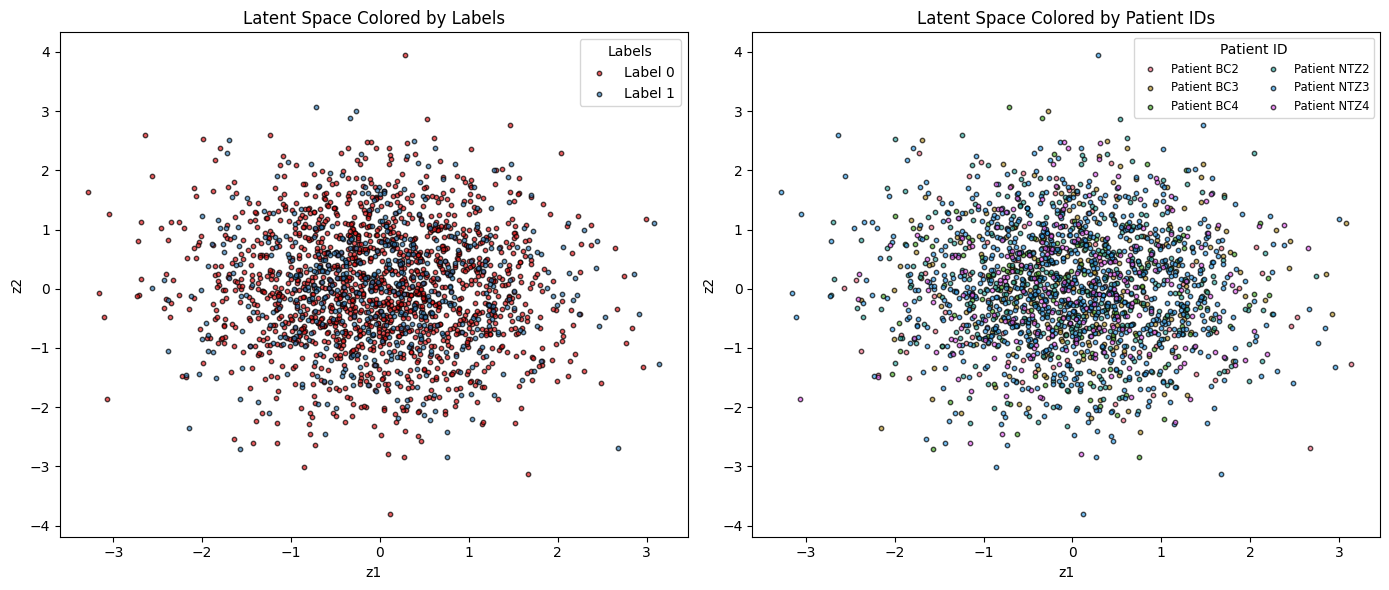

In [33]:
plot_full_latent_space(vae, btk_loader, device=device)

In [9]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    #reconstruction_loss = F.mse_loss(recon_x, x, reduction='mean')
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    #Reconstruction loss using ms_ssim
    #reconstruction_loss = 1 - ms_ssim(recon_x, x)
    
    # KL divergence (latent space regularization)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss, kl_divergence

In [9]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 20
kl_weight = 0.001
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    #kl_weight += 0.001
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    
    #epoch_reconstructed_images = []
    
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            step_start_time = time.time()  # Start step timer

            images, _, _ = batch
            images = images.to(device)

            t0 = time.time()
            optimizer.zero_grad()  # Zero gradients
            t1 = time.time()
            zero_grad_time = t1 - t0
            #print(f"zero_grad_time: {zero_grad_time:.4f}s")
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            t2 = time.time()
            forward_time = t2 - t1
            #print(f"forward_time: {forward_time:.4f}s")
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            
            t3 = time.time()
            loss_time = t3 - t2
            #print(f"loss_time: {loss_time:.4f}s")
            
            scaled_loss = recon_loss + kl_weight * kl_loss
            scaled_loss.backward()  # Backward pass
            t4 = time.time()
            backward_time = t4 - t3
            #print(f"backward_time: {backward_time:.4f}s")
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)  # Gradient clipping
            t5 = time.time()
            clip_time = t5 - t4
            #print(f"clip_time: {clip_time:.4f}s")
            
            optimizer.step()  # Optimizer step
            t6 = time.time()
            optimizer_time = t6 - t5
            #print(f"optimizer_time: {optimizer_time:.4f}s")

            step_time = t6 - step_start_time

            # Print timing for each operation
            print(f"Step {batch_idx + 1} times: zero_grad={zero_grad_time:.4f}s, forward={forward_time:.4f}s, loss_calc={loss_time:.4f}s, backward={backward_time:.4f}s, clip={clip_time:.4f}s, optimize={optimizer_time:.4f}s, total={step_time:.4f}s")

            # Accumulate losses for the epoch
            epoch_total_loss += scaled_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=scaled_loss.item()
            )
            
    #epoch_reconstructed_images = torch.cat(epoch_reconstructed_images, dim=0)
    #all_reconstructed_images.append(epoch_reconstructed_images)

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(btk_loader)
    avg_recon_loss = epoch_recon_loss / len(btk_loader)
    avg_kl_loss = epoch_kl_loss / len(btk_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(btk_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


Epoch 1:   2%|▏         | 1/64 [00:02<02:09,  2.06s/batch, kl_loss=66.9, recon_loss=2.52e+5, total_loss=2.52e+5]

Step 1 times: zero_grad=0.0016s, forward=0.4677s, loss_calc=0.0069s, backward=1.4977s, clip=0.0035s, optimize=0.0310s, total=2.0085s


Epoch 1:   3%|▎         | 2/64 [00:03<01:32,  1.49s/batch, kl_loss=9.78e+5, recon_loss=2.37e+5, total_loss=2.39e+5]

Step 2 times: zero_grad=0.0063s, forward=0.4939s, loss_calc=0.0055s, backward=0.5192s, clip=0.0030s, optimize=0.0226s, total=1.0506s


Epoch 1:   5%|▍         | 3/64 [00:04<01:17,  1.27s/batch, kl_loss=4.32e+4, recon_loss=2.17e+5, total_loss=2.17e+5]

...

Epoch 1:  12%|█▎        | 8/64 [00:13<01:44,  1.86s/batch, kl_loss=1.8e+4, recon_loss=1.81e+5, total_loss=1.81e+5] 

Step 8 times: zero_grad=0.0032s, forward=0.6739s, loss_calc=0.0101s, backward=1.1554s, clip=0.0025s, optimize=0.0213s, total=1.8664s


Epoch 1:  14%|█▍        | 9/64 [00:15<01:33,  1.70s/batch, kl_loss=1.91e+4, recon_loss=1.74e+5, total_loss=1.74e+5]

Step 9 times: zero_grad=0.0048s, forward=0.3590s, loss_calc=0.0043s, backward=0.5687s, clip=0.0021s, optimize=0.0261s, total=0.9653s


KeyboardInterrupt: 

In [ ]:
num_epochs = 20
kl_weight = 0.001
vae.train()
for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    total_loss = 0
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            step_start_time = time.time()  # Start step timer

            images, _, _ = batch
            images = images.to(device)

            t0 = time.time()
            optimizer.zero_grad()  # Zero gradients
            t1 = time.time()
            zero_grad_time = t1 - t0

            recon_images, mu, logvar = vae(images)  # Forward pass
            t2 = time.time()
            forward_time = t2 - t1

            loss, recon_loss, kl_loss = vae.loss_function(recon_images, images, mu, logvar, loss_type='ssim')  # Compute loss
            t3 = time.time()
            loss_time = t3 - t2

            loss.backward()  # Backward pass
            t4 = time.time()
            backward_time = t4 - t3

            optimizer.step()  # Optimizer step
            t5 = time.time()
            optimizer_time = t5 - t4

            step_time = t5 - step_start_time

            # Print timing for each operation
            print(f"Step {batch_idx + 1} times: zero_grad={zero_grad_time:.4f}s, forward={forward_time:.4f}s, loss_calc={loss_time:.4f}s, backward={backward_time:.4f}s, optimize={optimizer_time:.4f}s, total={step_time:.4f}s")

            total_loss += loss.item()
            tepoch.set_postfix(loss=loss.item() / len(images))

    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(btk_loader.dataset):.4f}")


In [ ]:
# Example usage:
# Make sure you have your VAE (vae) and your dataloader (btk_loader) defined
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#plot_latent_space(vae, btk_loader, device=device)


In [22]:
plot_latent_space_all(vae, btk_loader, device=device)

TypeError: expected Tensor as element 0 in argument 0, but got tuple

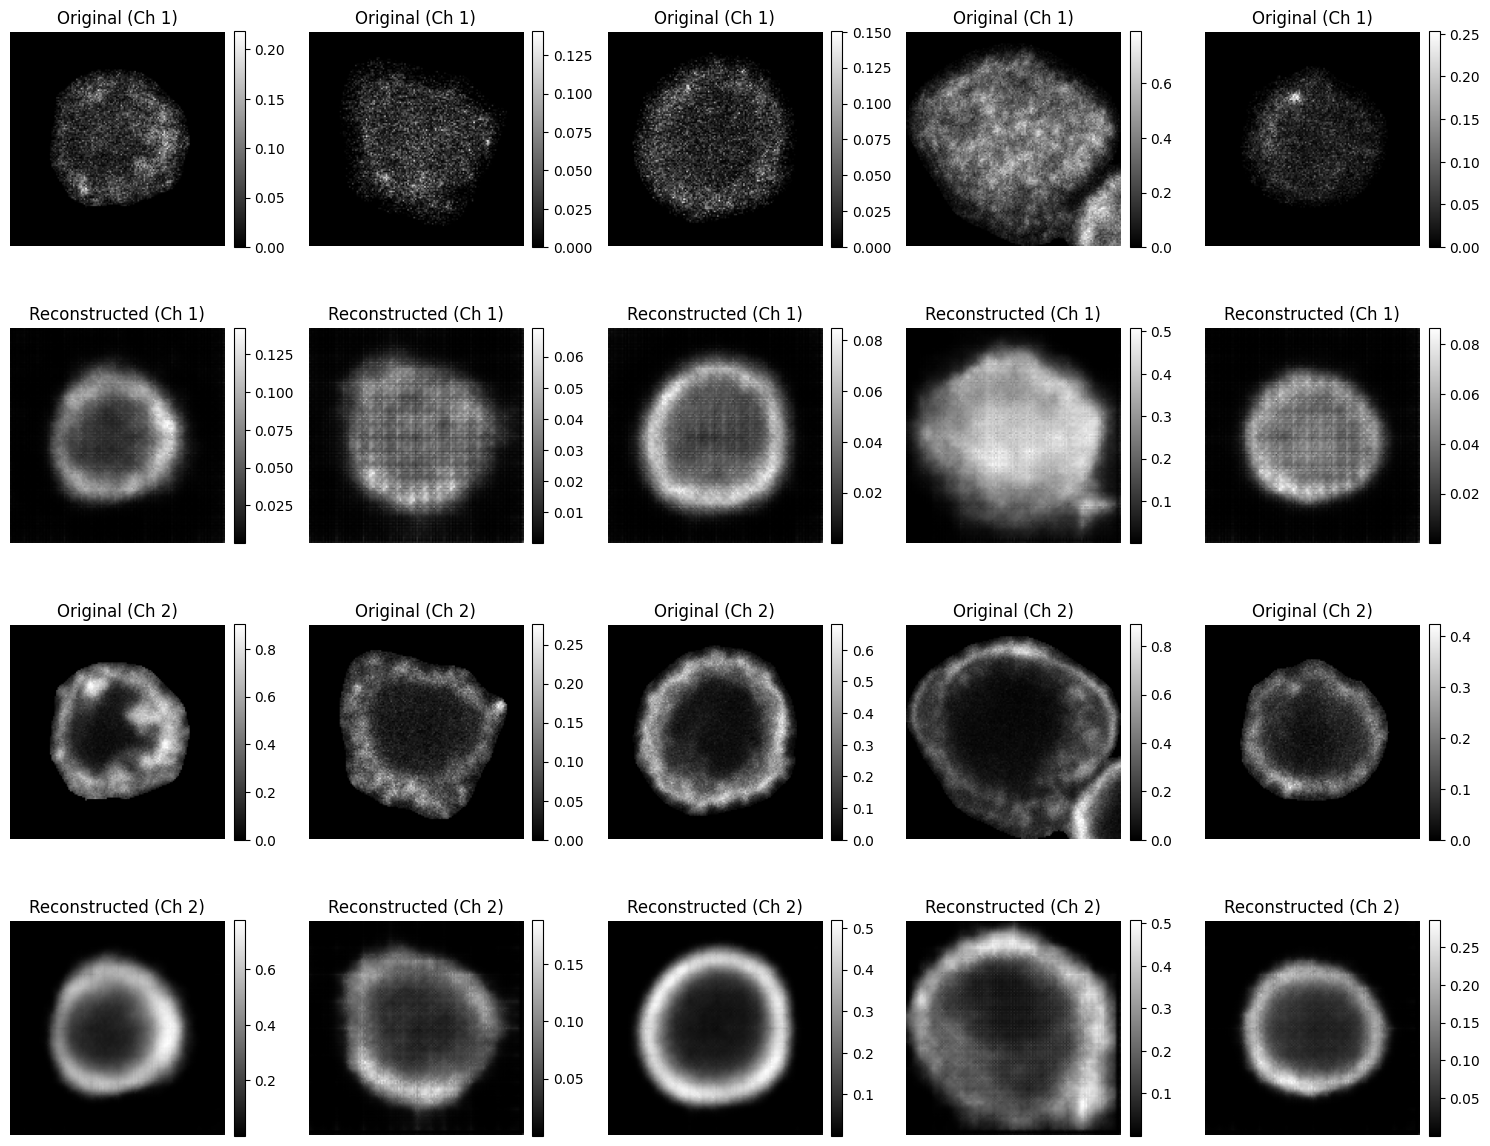

In [17]:
visualize_reconstructions(vae, btk_loader, device)

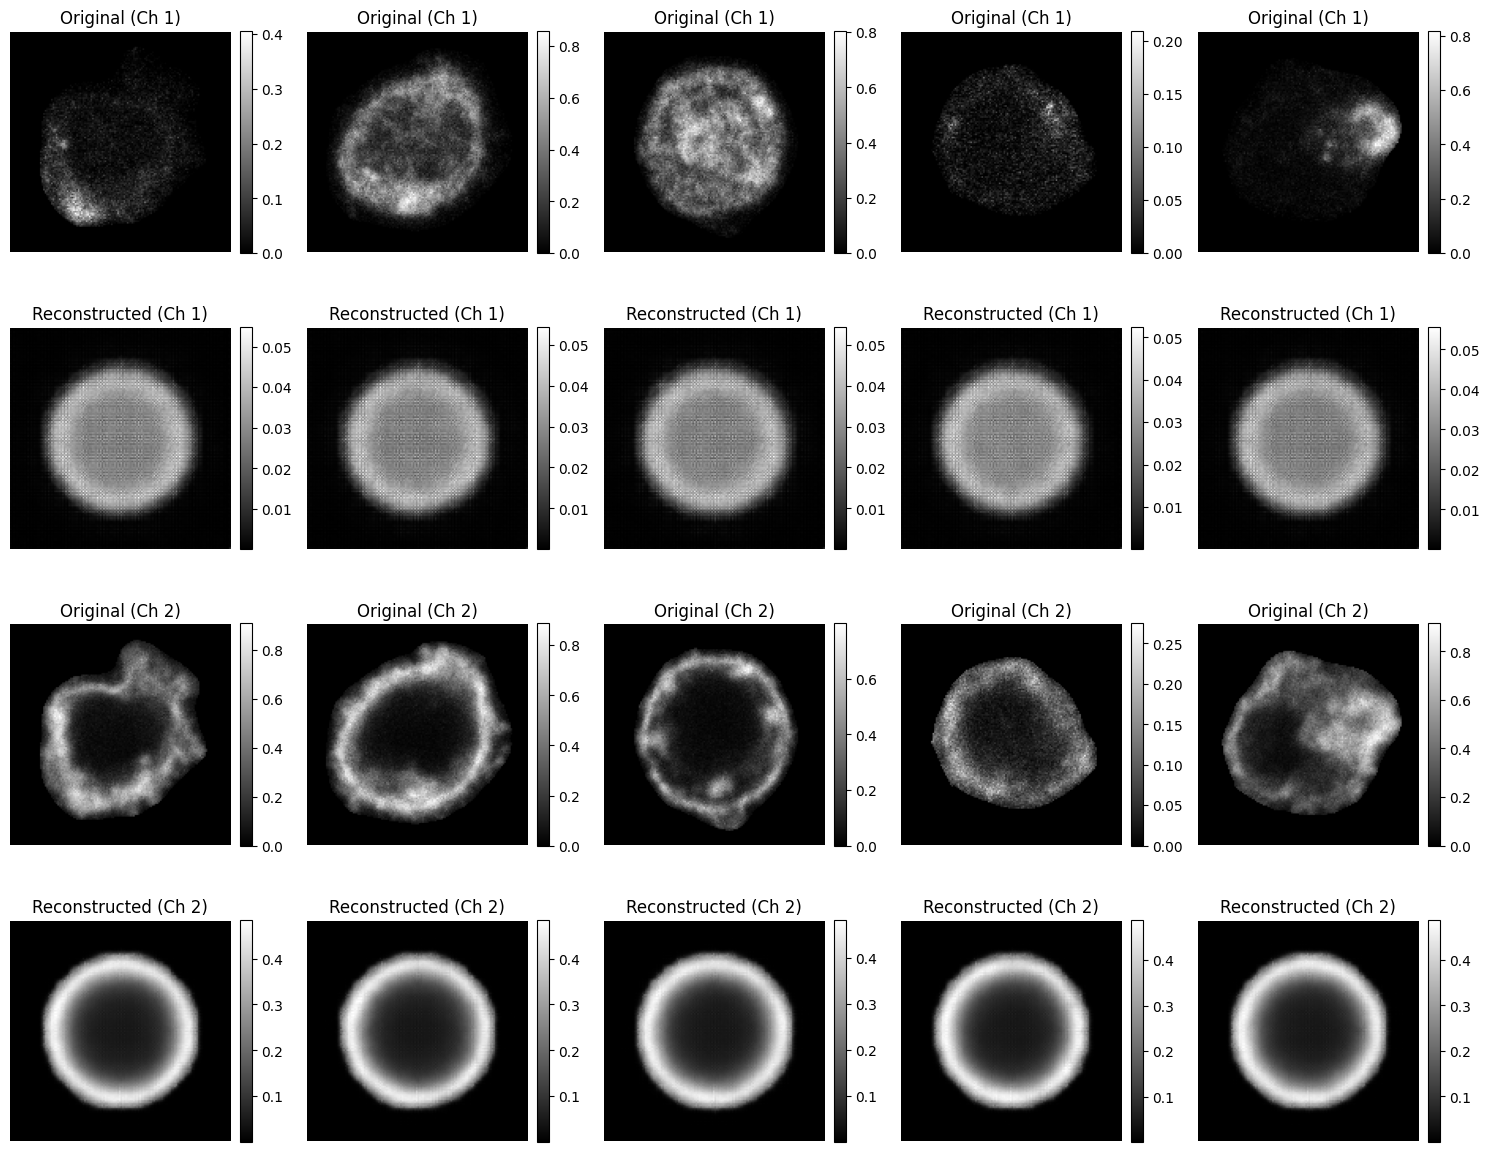

In [12]:
visualize_reconstructions(vae, btk_loader, device)

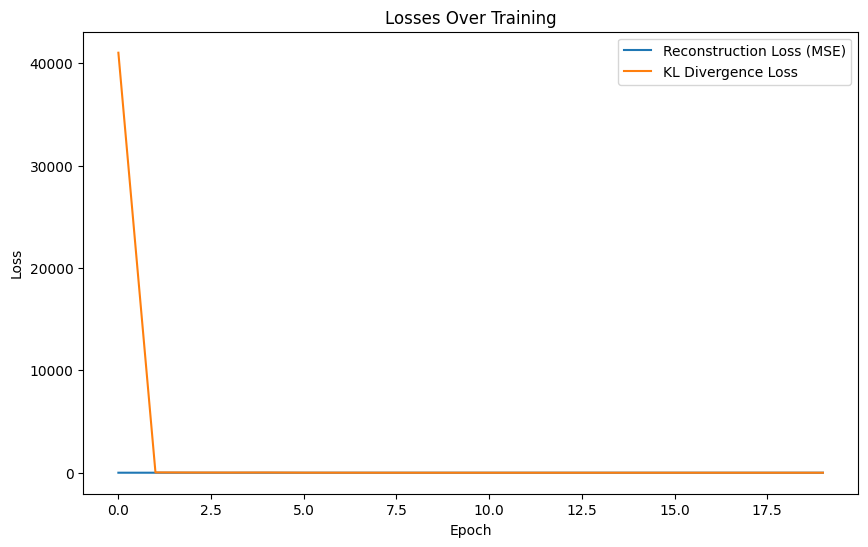

In [13]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

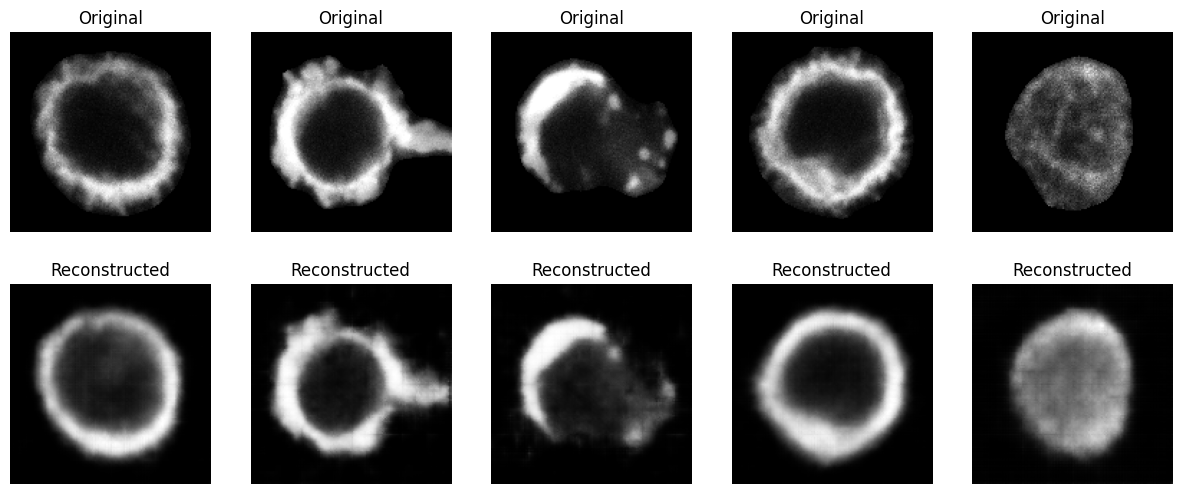

In [41]:
visualize_reconstructions(vae, btk_loader, device)

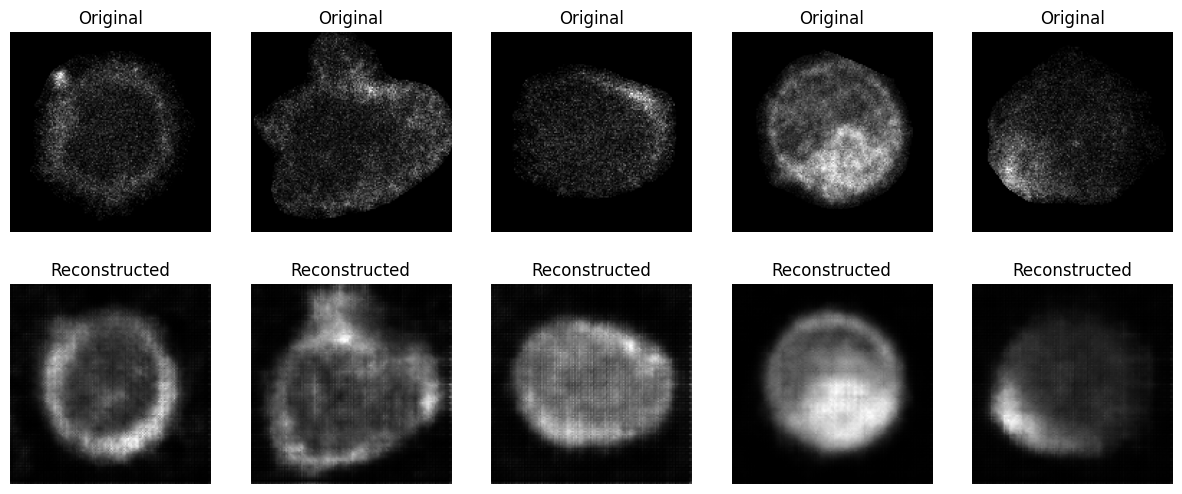

In [25]:
visualize_reconstructions(vae, btk_loader, device)

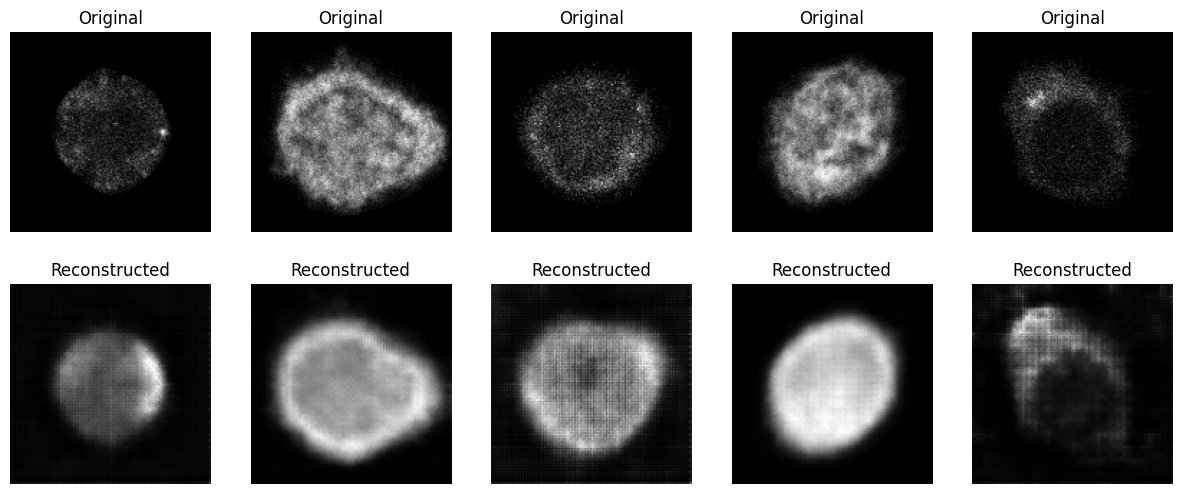

In [14]:
visualize_reconstructions(vae, btk_loader, device)

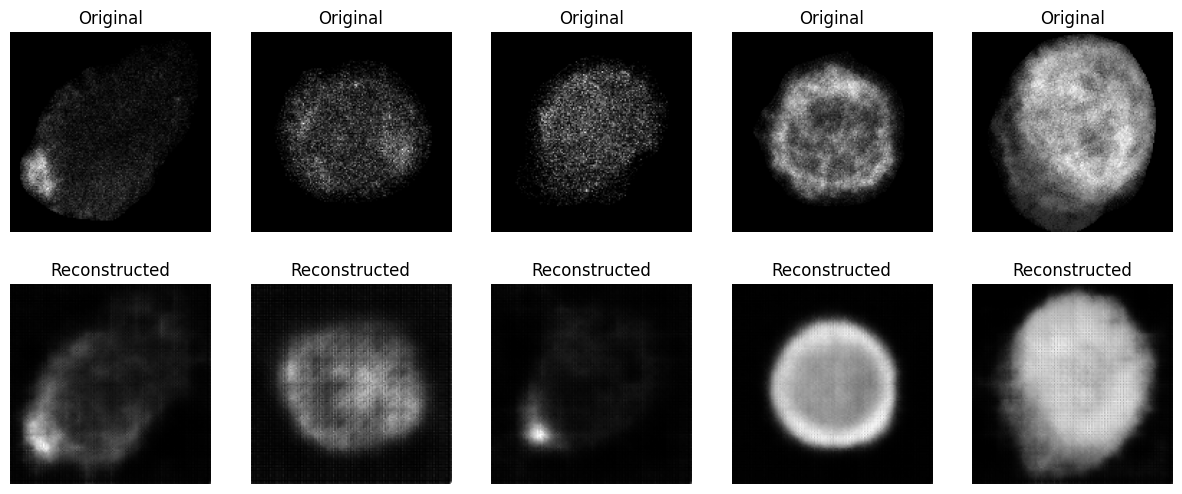

In [ ]:
#4th approach
visualize_reconstructions(vae, btk_loader, device)

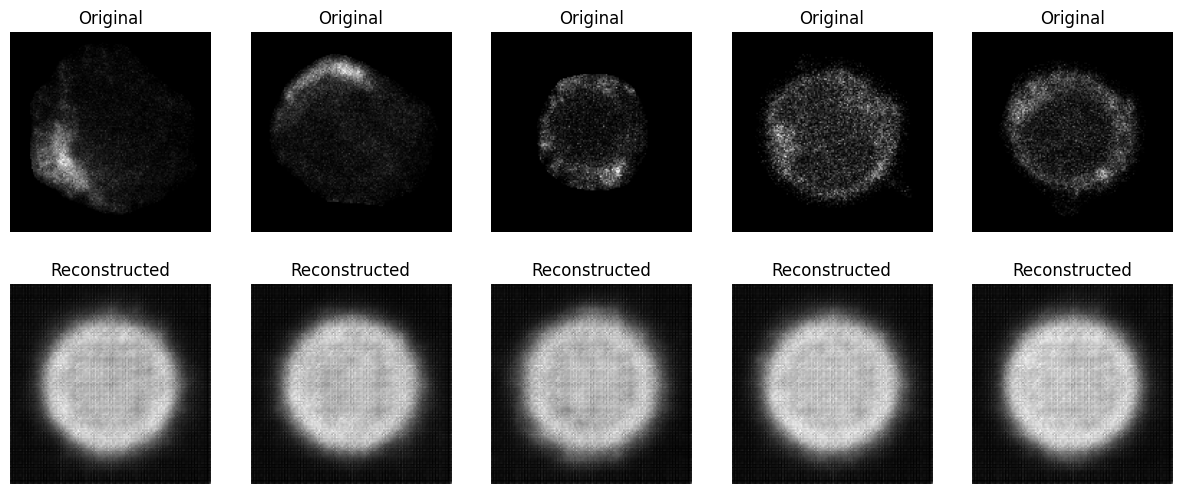

In [ ]:
#3rd approach
visualize_reconstructions(vae, btk_loader, device)

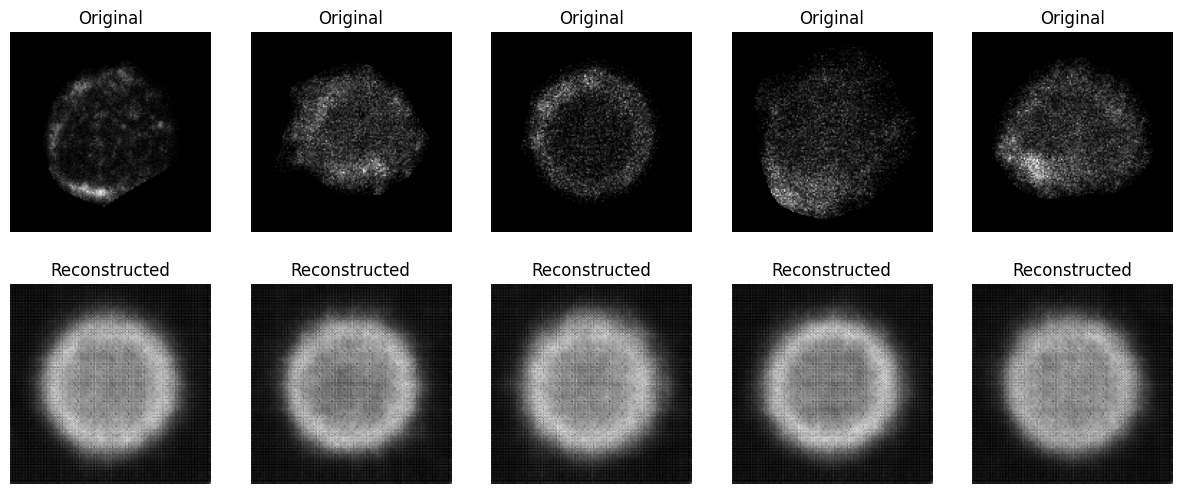

In [ ]:
#2nd approach
visualize_reconstructions(vae, btk_loader, device)

In [11]:
recon_images, _, _ = vae(images)

In [33]:
final_reconstructed_images.shape

torch.Size([1786, 2, 140, 140])

In [27]:
all_reconstructed_images.max()

tensor(0.9993, grad_fn=<MaxBackward1>)

In [12]:
reconstruction_losses

[102205.21104213169,
 13135.791224888393,
 6465.608415876116,
 5344.993504115513,
 5098.846984863281,
 4762.232221330915,
 4545.416944231306,
 5173.669821602957,
 4095.4273986816406,
 4040.54012625558,
 3641.5435834612167,
 3575.0396815708705,
 3557.9722508021764,
 3419.4813058035716,
 3311.1634041922434,
 3412.8641531808034,
 3214.287061418806,
 3179.8038199288503,
 3249.287602015904,
 3130.9871956961497]

In [13]:
kl_losses

[1361514.199132647,
 58792.89271763393,
 47331.51677594866,
 28257.534144810266,
 23295.94841657366,
 18181.71805245536,
 15675.3515625,
 18701177.05280413,
 9291.445626395089,
 8496.84188406808,
 6718.570861816406,
 5678.395882742746,
 5122.754276820591,
 4276.619829450335,
 3863.5709184919083,
 3783.1997898646764,
 3508.024727957589,
 3385.19864327567,
 3278.0074157714844,
 3115.7891932896205]

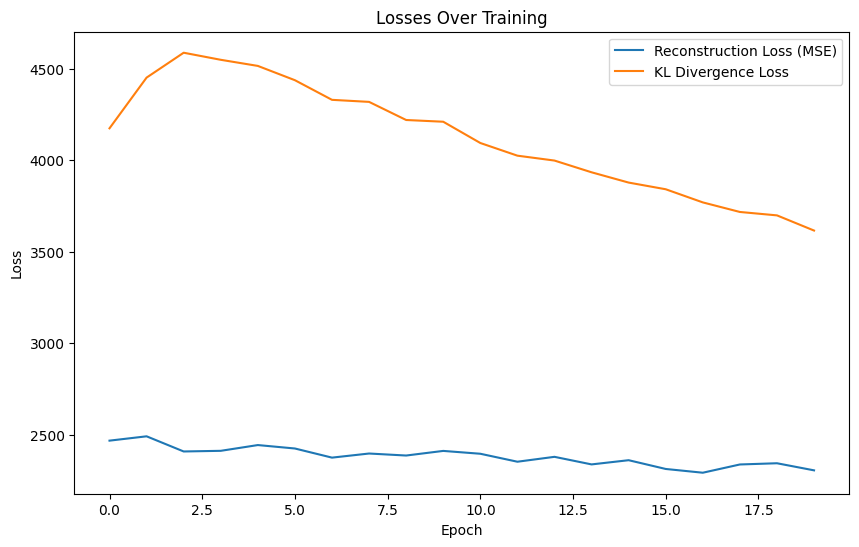

In [32]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

In [ ]:
encoder = Encoder()
mu, sigma = encoder(x)
std = torch.exp(0.5 * sigma)
eps = torch.randn_like(std)
z = mu + eps * std
